In [1]:
import pickle
import time
import warnings
import itertools
import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse
import shapely
import tqdm
import quadpy
import cdd
import warnings
from random_matrix.amplitude_matrix import isotropic_sphere
from random_matrix.input_statistics import density_function, density_integrals
from random_matrix.input_statistics.density_function import (
    DeltaDensityFactor,
    DensityFunction,
    DensityFunctionTerm,
    RegularDensityFactor,
)
from random_matrix.input_statistics.index_finder import IndexFinder
from random_matrix.input_statistics.input_statistics_manager import (
    InputStatisticsManager,
)
from random_matrix.input_statistics.integration_task import (
    IntegrationTaskPreparer,
)
from random_matrix.input_statistics.medium_parameters import MediumParameters
from random_matrix.input_statistics.medium_statistics import (
    MediumStatistics,
    ParticleStatistics,
)
from random_matrix.modes import mode_grid, mode_grid_factory
from random_matrix.utils import (
    array_utils,
    function_utils,
    geometry_utils,
    integration_utils,
    matrix_utils,
    special_functions,
)
from random_matrix.scattering_matrix import sampler

In [2]:
# Figure out appropriate set of side lengths for modes in units of hundreds
side_lengths = np.array(
    [
        0.2,
        0.135,
        0.108,
        0.094,
        0.0831,
        0.075,
        0.07,
        0.065,
        0.061,
        0.058,
        0.055,
        0.05,
        0.04,
        0.03,
        0.01,
    ]
)
num_modes = []
for side_length in side_lengths[[2]]:
    my_grid = mode_grid_factory.from_tiling(
        tiling_type="rectangles",
        side_length=(side_length, side_length),
        r_lim=1.2,
        grid_wave_type="propagating",
        rotation_angle=0.0,
        translation_vector=np.array([0.0, 0.0]),
    )
    print(my_grid.num_propagating)
    print(f"Aim: {len(side_lengths)*100}")
    num_modes.append(my_grid.num_propagating)
# num_modes = np.array([101, 201, 305, 405, 509, 609, 697, 793, 905, 1005])
print(num_modes)

305
Aim: 1500
[305]


In [21]:
dirac_data = []
dirac_time = []
mean_data = []
mean_time = []
middle_weights = []

for side_length in tqdm.tqdm(side_lengths[[1]]):
    my_grid = mode_grid_factory.from_tiling(
        tiling_type="rectangles",
        side_length=(side_length, side_length),
        r_lim=1.2,
        grid_wave_type="propagating",
        rotation_angle=0.0,
        translation_vector=np.array([0.0, 0.0]),
    )
    middle_weights.append(my_grid.by_index(0).weight)
    wavelength = 550e-9
    slab_thickness = 1.8992695221776513e-4
    number_density = 5.921762640653617e17
    medium_parameters = MediumParameters(
        wavelength=wavelength,
        number_density=number_density,
        slab_thickness=slab_thickness,
    )
    term = DensityFunctionTerm.from_delta({"x": 2.0, "m": 1.2})
    particle_statistics = ParticleStatistics(
        term,
        isotropic_sphere.get_A,
        isotropic_sphere.get_A_product,
        isotropic_sphere.get_A_product_conj,
    )
    medium_statistics = MediumStatistics([particle_statistics])

    # Set up the relevant indices
    propagating_indices = my_grid.propagating_indices
    quads = [(0, i, 0, i) for i in propagating_indices]
    quads = [(0,0,0,0)]
    first = [
        "pp,pp",
        "pp,pe",
        "pp,ep",
        "pp,ee",
        "pe,pe",
        "pe,pe",
        "pe,ep",
        "pe,ee",
        "ep,ep",
        "ep,ee",
        "ee,ee",
    ]
    second = [
        "t,t",
        "t,r",
        "t,t2",
        "t,r2",
        "r,r",
        "r,t2",
        "r,r2",
        "t2,t2",
        "t2,r2",
        "r2,r2",
    ]
    supplied_indices = {
        "covariance": {key1: {key2: [] for key2 in second} for key1 in first}
    }
    for key in ["t,t", "r,r"]:
        supplied_indices["covariance"]["pp,pp"][key] = quads
    for key in ["t,t"]:
        supplied_indices["covariance"]["pp,pp"][key] = quads

    # DIRAC DELTA ONE
    simulation_name = f"test_dirac_{side_length}"
    input_statistics_manager = InputStatisticsManager(
        simulation_name,
        medium_parameters,
        medium_statistics,
        my_grid,
        supplied_indices=supplied_indices,
        use_dirac_density=True,
        covariance_cubature_scheme=quadpy.t2.get_good_scheme(20)
    )
    integration_result_list, tee = input_statistics_manager.get_statistics()
    dirac_data.append(integration_result_list)
    dirac_time.append(tee)

    # NON DIRAC DELTA ONE
    simulation_name = f"test_mean_{side_length}"
    input_statistics_manager = InputStatisticsManager(
        simulation_name,
        medium_parameters,
        medium_statistics,
        my_grid,
        supplied_indices=supplied_indices,
        use_dirac_density=False,
        covariance_cubature_scheme=None
    )
    integration_result_list, tee = input_statistics_manager.get_statistics()
    mean_data.append(integration_result_list)
    mean_time.append(tee)
    # cov_results = integration_result_list.by_statistic_type("covariance")
    # results = cov_results.results

    # y = [np.linalg.norm(r.integral) for r in results]


  0%|          | 0/1 [00:00<?, ?it/s]/tmp/ipykernel_3448896/3363834962.py:73: UserWarning: No parent_data_dir provided. Defaulting to current working directory: /home/nbyrnes/code/random-matrix/data.
  input_statistics_manager = InputStatisticsManager(


[06/16 13:02:05] Prepare covariance tasks


/home/nbyrnes/code/random-matrix/random_matrix/amplitude_matrix/scattering_geometry.py:30: RuntimeWarning: invalid value encountered in divide
  e_phi /= mod_kappa[..., xp.newaxis]
/home/nbyrnes/code/random-matrix/random_matrix/amplitude_matrix/scattering_geometry.py:44: RuntimeWarning: invalid value encountered in divide
  e_theta /= xp.sqrt(
100%|██████████| 1/1 [00:00<00:00, 128.11it/s]

[06/16 13:02:05] Done



/tmp/ipykernel_3448896/3363834962.py:88: UserWarning: No parent_data_dir provided. Defaulting to current working directory: /home/nbyrnes/code/random-matrix/data.
  input_statistics_manager = InputStatisticsManager(


[06/16 13:02:06] Prepare covariance tasks


100%|██████████| 1/1 [00:00<00:00,  1.68it/s]


[06/16 13:02:07] Done


100%|██████████| 1/1 [00:03<00:00,  3.28s/it]


In [22]:
dirac_norms = []
mean_norms = []

for result_list in dirac_data:
    for result in result_list.results:
        if (
            "t,t" in result.block_location
            and (0, 0, 0, 0) in result.sub_block_locations
        ):
            dirac_norms.append(np.linalg.norm(result.integral))

dirac_norms = np.array(dirac_norms)*np.array(middle_weights)**2

for result_list in mean_data:
    for result in result_list.results:
        if (
            "t,t" in result.block_location
            and (0, 0, 0, 0) in result.sub_block_locations
        ):
            # # Get index
            for i, s in enumerate(result.sub_block_locations):
                if s == (0,0,0,0):
                    break
            mean_norms.append(np.linalg.norm(result.integral[i]))
mean_norms = np.array(mean_norms)
print(dirac_norms)
print(mean_norms)

[9.73401724e-06]
[1.08597271e-06]


In [23]:
print(dirac_norms/mean_norms)

[8.96340866]


In [24]:
dirac_time

[0.01105160778388381]

Text(0, 0.5, 'Mean time / Dirac time')

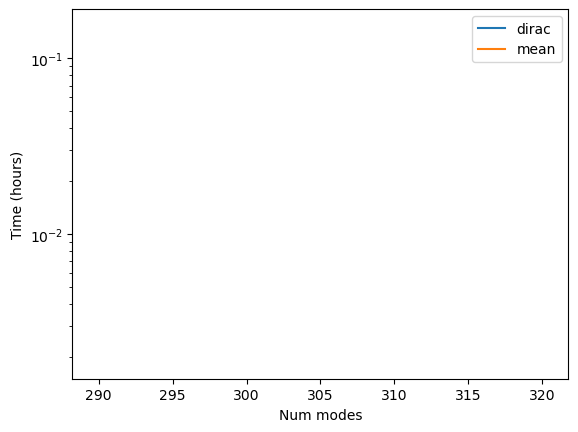

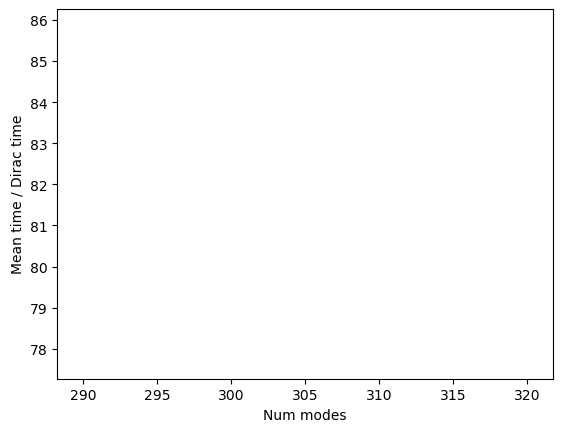

In [25]:
# Time graph
total_dirac_time = np.array(dirac_time)*np.array(num_modes) *2 / 60**2
total_mean_time = np.array(mean_time)*np.array(num_modes) *2 / 60**2
x = np.array(num_modes)

fig, ax = plt.subplots()
ax.plot(x, total_dirac_time, label="dirac")
ax.plot(x, total_mean_time, label="mean")
ax.set_yscale("log")
ax.set_ylabel("Time (hours)")
ax.set_xlabel("Num modes")
ax.legend()

fig, ax = plt.subplots()
ax.plot(x, np.array(mean_time)/np.array(dirac_time))
ax.set_xlabel("Num modes")
ax.set_ylabel("Mean time / Dirac time")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0.5, 1.0, 'Norms of direct transmission scaled by mode size')

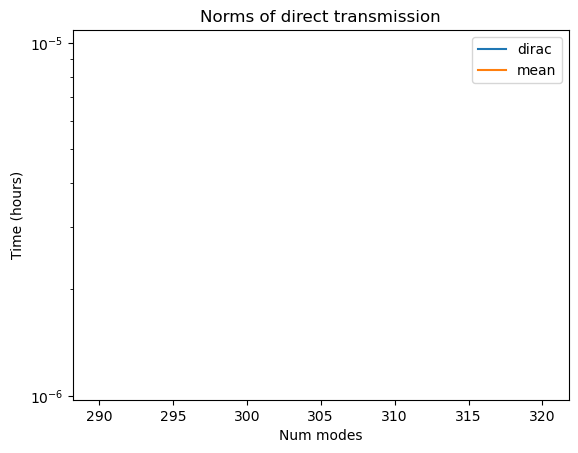

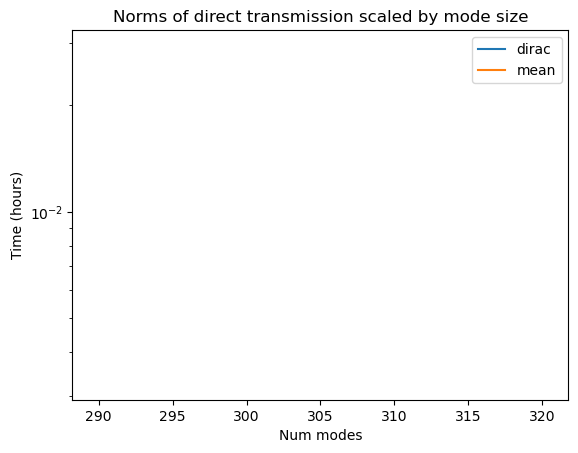

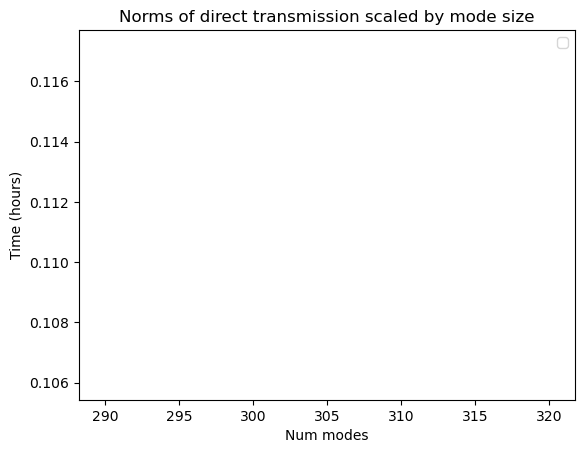

In [26]:
# Convergence of results
fig, ax = plt.subplots()
ax.plot(x, dirac_norms, label="dirac")
ax.plot(x, mean_norms, label="mean")
ax.set_yscale("log")
ax.set_ylabel("Time (hours)")
ax.set_xlabel("Num modes")
ax.legend()
ax.set_title("Norms of direct transmission")

# Scaled by middle weights
fig, ax = plt.subplots()
ax.plot(x, dirac_norms/(np.array(middle_weights)**2), label="dirac")
ax.plot(x, mean_norms/(np.array(middle_weights)**2), label="mean")
ax.set_yscale("log")
ax.set_ylabel("Time (hours)")
ax.set_xlabel("Num modes")
ax.legend()
ax.set_title("Norms of direct transmission scaled by mode size")

# Ratio of data
fig, ax = plt.subplots()
ax.plot(x, mean_norms/dirac_norms)
ax.set_ylabel("Time (hours)")
ax.set_xlabel("Num modes")
ax.legend()
ax.set_title("Norms of direct transmission scaled by mode size")


In [27]:
mean_norms / dirac_norms

array([0.1115647])

In [148]:
square = 1e-5*(np.array([[0,0],[1,0],[1,1],[0,1]]) - 0.5)
base = geometry_utils.iterated_cartesian_product([square, square, square, square])
area = scipy.spatial.ConvexHull(square).volume

# Six dimensions
reduced_intersection = geometry_utils.get_intersection_vertices(
    base
)
reduced_hull = scipy.spatial.ConvexHull(
    reduced_intersection, qhull_options="QJ"
)
six_vol = reduced_hull.volume

# Two dimensions
intersection = (
    geometry_utils.get_intersection_vertices_dirac_density(
        base, (0.0,0.0), (0.0,0.0)
    )
)
reduced_region = intersection[:, [0,1]]
print(reduced_region)
reduced_hull = scipy.spatial.ConvexHull(
    reduced_region, qhull_options="QJ"
)
two_vol = reduced_hull.volume*area*area

print(area)
print(six_vol)
print(two_vol)
print(six_vol/two_vol)
print(two_vol/six_vol)

[[ 5.e-06 -5.e-06]
 [ 5.e-06  5.e-06]
 [-5.e-06  5.e-06]
 [-5.e-06 -5.e-06]]
1.0000000000000002e-10
4.444452946797865e-31
9.999992254691358e-31
0.44444563891665134
2.2499939530007045


In [149]:
new_base = geometry_utils.iterated_cartesian_product([square, square])
t = np.ones(len(new_base))
polytope_mat = cdd.matrix_from_array(
    np.column_stack((t.T, new_base)), rep_type=cdd.RepType.GENERATOR
)
polytope = cdd.polyhedron_from_matrix(polytope_mat)
polytope_inequalities = np.array(cdd.copy_inequalities(polytope).array)
correlation_signature = [1, -1, -1, 1]
a, b, c, d = correlation_signature
hyperplane_equations = np.array(
    [
        [0, a, 0, c, 0],
        [0, 0, a, 0, c],
    ]
)
lin_set = set([0, 1])
augmented_inequalities = np.vstack(
    (hyperplane_equations, polytope_inequalities)
)
intersection_mat = cdd.matrix_from_array(
    augmented_inequalities,
    rep_type=cdd.RepType.INEQUALITY,
    lin_set=lin_set,
)
intersection = cdd.polyhedron_from_matrix(intersection_mat)
intersection_vertices = np.array(cdd.copy_generators(intersection).array)
truncated_vertices = intersection_vertices[:, 1:]
two_d_cols = truncated_vertices[:,0:2]
reduced_hull = scipy.spatial.ConvexHull(
    two_d_cols, qhull_options="QJ"
)
two_vol_two = reduced_hull.volume*area*area
print(two_vol_two)
print(two_vol)
print(six_vol)
print(six_vol/two_vol)


9.99999225469138e-31
9.999992254691358e-31
4.444452946797865e-31
0.44444563891665134


In [ ]:

t = xp.ones(len(vertices))
polytope_mat = cdd.matrix_from_array(
    xp.column_stack((t.T, vertices)), rep_type=cdd.RepType.GENERATOR
)

# Get the halfspace representation inequalities
polytope = cdd.polyhedron_from_matrix(polytope_mat)
polytope_inequalities = xp.array(cdd.copy_inequalities(polytope).array)

# Intersect the polytope with the hyperplanes
if correlation_signature is None:
    correlation_signature = [1, -1, -1, 1]
a, b, c, d = correlation_signature
hyperplane_equations = xp.array(
    [
        [0, a, 0, b, 0, c, 0, d, 0],
        [0, 0, a, 0, b, 0, c, 0, d],
        [kj[0], 0, 0, -1, 0, 0, 0, 0, 0],
        [kj[1], 0, 0, 0, -1, 0, 0, 0, 0],
        [kv[0], 0, 0, 0, 0, 0, 0, -1, 0],
        [kv[1], 0, 0, 0, 0, 0, 0, 0, -1],
    ]
)
lin_set = set([0, 1, 2, 3, 4, 5])
augmented_inequalities = xp.vstack(
    (hyperplane_equations, polytope_inequalities)
)
intersection_mat = cdd.matrix_from_array(
    augmented_inequalities,
    rep_type=cdd.RepType.INEQUALITY,
    lin_set=lin_set,
)
intersection = cdd.polyhedron_from_matrix(intersection_mat)
intersection_vertices = xp.array(cdd.copy_generators(intersection).array)

# Truncate the
truncated_vertices = intersection_vertices[:, 1:]

